# Plot utilities demo

Notebook de validación visual interactiva para todas las funciones públicas de `ds_utils.eda.plot_utilities`.

Cada sección incluye:
1. Una breve explicación del propósito de la función y de los elementos visuales a verificar.
2. Datos sintéticos autocontenidos y reproducibles.
3. La invocación real a la función para inspeccionar la figura resultante.

In [5]:
# RECARGA AUTOMÁTICA DE MÓDULOS EXTERNOS
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

# Configuración canónica y clase de nombres y sufijos de características
from ds_utils.preprocessing.preprocessing_config import (
    FEATURES_CONFIG,
    FeatureNamingConfig,
)

# Dependencia opcional del extra EDA plot_utilities
try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError(
        "This notebook requires the EDA dependencies. "
        "Install them with: uv sync --extra eda"
    ) from exc

# Funciones públicas a validar
from ds_utils.eda.plot_utilities import (
    bold_matplotlib,
    plot_circular_feature,
    plot_sensor_signals,
    plot_model_anomaly_scores,
    plot_model_anomaly_score_distribution,
    plot_model_predictions,
    plot_model_feature_importance,
    plot_feature_space_projection,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## `bold_matplotlib`

* **Qué hace**: Genera una expresión MathText para representar un texto en negrita cuando se utiliza en elementos de texto de Matplotlib. Está pensada especialmente para combinar texto normal y texto en negrita dentro del mismo título, etiqueta o anotación.

* **Parámetros**:

  * `text` (`str`): Texto que se desea representar en negrita.

* **Qué devuelve**:

  * `str`: Expresión MathText que puede utilizarse en elementos de texto de Matplotlib para representar el texto en negrita.


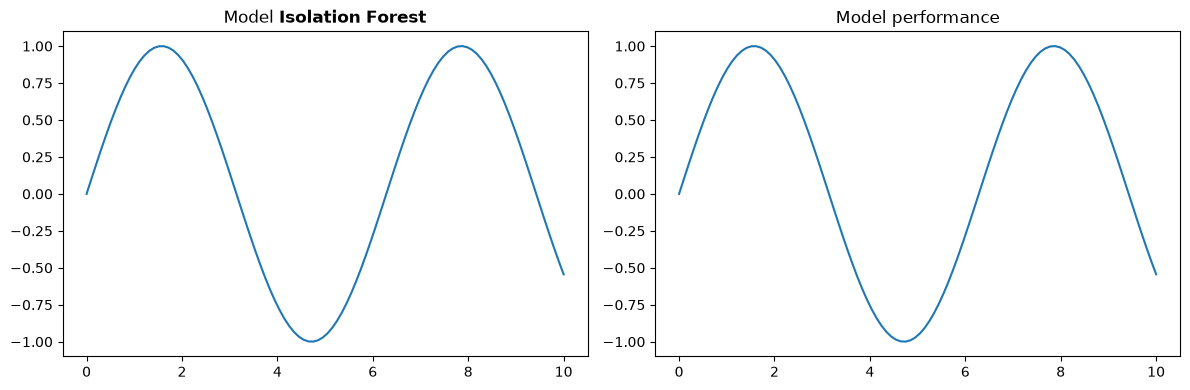

In [6]:
# Comparamos un título con texto en negrita dentro de la cadena frente a uno normal.

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Con bold()
axes[0].plot(x, y)
axes[0].set_title(f"Model {bold_matplotlib("Isolation Forest")}")

# Sin bold()
axes[1].plot(x, y)
axes[1].set_title("Model performance")

plt.tight_layout()
plt.show()


---
## 1. `plot_circular_feature`

### Qué comprobar visualmente:
- Los puntos en el diagrama de dispersión (*scatter plot*) deben formar una trayectoria circular o elíptica cerrada correspondiente al ciclo periódico.
- Deben visualizarse dos líneas discontinuas de referencia que marcan los cuadrantes cartesianos en `x = 0` e `y = 0`.
- Las etiquetas de los ejes deben mostrar respectivamente las columnas pasadas en `col_cos` (eje horizontal) y `col_sin` (eje vertical).
- Debe apreciarse la cuadrícula suave (`grid`) y el título personalizado o por defecto.

In [ ]:
# ---------------------------------------------------------------------------
# Datos sintéticos: 24 horas del día transformadas en seno y coseno
# ---------------------------------------------------------------------------
hours = np.arange(24)
angles = 2 * np.pi * hours / 24

df_circular = pd.DataFrame({
    "hour_sin": np.sin(angles),
    "hour_cos": np.cos(angles),
})

# Invocación con título personalizado
plot_circular_feature(
    df=df_circular,
    col_sin="hour_sin",
    col_cos="hour_cos",
    title="Representación Cíclica - Horas del Día (0-23h)",
)

---
## 2. `plot_sensor_signals`

### Qué comprobar visualmente:
- **Señal Raw** (línea gris): Traza la señal original completa incluyendo los picos y perturbaciones de ruido.
- **Señal Limpio** (línea verde): Traza la señal corregida superpuesta (utilizando el sufijo limpio configurado), donde los picos han sido reemplazados.
- **Ruido Detectado** (puntos rojos): Puntos de dispersión ubicados exactamente sobre las muestras anómalas (donde la columna con el sufijo de ruido es `True`).
- **Título**: Debe formatear correctamente el umbral configurado con estilo LaTeX (`Umbral: > X`).
- **Leyenda**: Debe incluir claramente `Raw`, `Limpio` y `Ruido Detectado`.
- **Caso 1 (Configuración por defecto)**: Utiliza la instancia canónica `FEATURES_CONFIG` (`_clean` e `_is_noise`).
- **Caso 2 (Configuración personalizada)**: Utiliza una instancia personalizada `FeatureNamingConfig` con sufijos en español (`_filtrado` y `_es_anomalia`), verificando que la función reconoce la configuración provista.

In [ ]:
# ---------------------------------------------------------------------------
# Caso 1: Configuración por defecto de la librería (FEATURES_CONFIG)
# ---------------------------------------------------------------------------
dates = pd.date_range("2026-03-01 00:00", periods=96, freq="15min")
base_signal = 22.0 + 4.0 * np.sin(np.linspace(0, 4 * np.pi, len(dates)))

raw_signal = base_signal.copy()
noise_indices = [18, 45, 72]
raw_signal[noise_indices] += np.array([16.0, -14.0, 20.0])

clean_signal = base_signal.copy()
is_noise = np.zeros(len(dates), dtype=bool)
is_noise[noise_indices] = True

sensor_name = "temperatura"
df_sensors = pd.DataFrame({
    "timestamp": dates,
    sensor_name: raw_signal,
    f"{sensor_name}{FEATURES_CONFIG.CLEAN_SUFFIX}": clean_signal,
    f"{sensor_name}{FEATURES_CONFIG.IS_NOISE_SUFFIX}": is_noise,
})

plot_sensor_signals(
    df=df_sensors,
    col_time="timestamp",
    tolerances={sensor_name: 8.0},
)

# ---------------------------------------------------------------------------
# Caso 2: Configuración personalizada mediante FeatureNamingConfig
# ---------------------------------------------------------------------------
custom_config = FeatureNamingConfig(
    CLEAN_SUFFIX="_filtrado",
    IS_NOISE_SUFFIX="_es_anomalia",
)

sensor_custom = "presion"
base_pressure = 100.0 + 10.0 * np.sin(np.linspace(0, 4 * np.pi, len(dates)))

raw_pressure = base_pressure.copy()
noise_pressure_idx = [25, 60]
raw_pressure[noise_pressure_idx] += np.array([35.0, -40.0])

clean_pressure = base_pressure.copy()
is_pressure_noise = np.zeros(len(dates), dtype=bool)
is_pressure_noise[noise_pressure_idx] = True

df_sensors_custom = pd.DataFrame({
    "timestamp": dates,
    sensor_custom: raw_pressure,
    f"{sensor_custom}{custom_config.CLEAN_SUFFIX}": clean_pressure,
    f"{sensor_custom}{custom_config.IS_NOISE_SUFFIX}": is_pressure_noise,
})

plot_sensor_signals(
    df=df_sensors_custom,
    col_time="timestamp",
    tolerances={sensor_custom: 15.0},
    config=custom_config,
)

---
## 3. `plot_model_anomaly_scores`

### Qué comprobar visualmente:
- **Señal de Score** (línea azul): Curva temporal con la evolución del score devuelto por el estimador.
- **Anomalías** (puntos rojos): Marcadores destacados únicamente en aquellas observaciones cuyo score es menor o igual al umbral (`score <= anomaly_threshold`).
- **Línea de Umbral** (línea negra discontinua): Marcando el valor exacto del umbral de decisión (`Threshold (0.0)`).
- **Eje temporal**: Las fechas deben mostrar un formato conciso y ordenado gracias a `AutoDateLocator` y `ConciseDateFormatter`.

In [ ]:
# ---------------------------------------------------------------------------
# Datos sintéticos: Serie temporal de scores con anomalías puntuales
# ---------------------------------------------------------------------------
np.random.seed(42)
timestamps = pd.date_range("2026-04-01 00:00", periods=120, freq="1h")

# Scores normales centrados en 0.4 con ruido suave
scores = 0.4 + 0.12 * np.random.randn(len(timestamps))

# Caídas abruptas por debajo del umbral de decisión (0.0)
anomaly_idx = [15, 48, 85, 110]
scores[anomaly_idx] = [-0.35, -0.65, -0.25, -0.80]

df_anomaly = pd.DataFrame({
    "fecha": timestamps,
    "score": scores,
})

plot_model_anomaly_scores(
    df=df_anomaly,
    col_time="fecha",
    col_score="score",
    anomaly_threshold=0.0,
    title="Monitoreo de Scores y Detección de Anomalías",
)

---
## 4. `plot_model_anomaly_score_distribution`

### Qué comprobar visualmente:
- **Dos histogramas superpuestos**:
  - Grupo `Normal` (azul semi-transparente): Todas las observaciones con `score > threshold`.
  - Grupo `Anomaly` (naranja semi-transparente): Todas las observaciones con `score <= threshold`.
- **Línea vertical negra** (`Threshold`): Delimita de forma nítida la frontera entre ambas poblaciones.
- Título del gráfico y etiquetas de recuento (`Count`) y score (`Anomaly score`).

In [ ]:
# Reutilizamos los scores sintéticos generados en la sección anterior
plot_model_anomaly_score_distribution(
    df=df_anomaly,
    col_score="score",
    anomaly_threshold=0.0,
    bins=25,
    title="Distribución de Scores de Anomalía vs Observaciones Normales",
)

---
## 5. `plot_model_predictions`

### Qué comprobar visualmente:
- **Traza Realidad** (línea continua) vs **Traza Predicción** (línea discontinua).
- **Eje X temporal**: Comprobar que toma correctamente las fechas provistas en el `DatetimeIndex` de la serie `y_real`.
- **Cálculo de MAE en título**: Cuando `mae=None`, la función calcula automáticamente el error absoluto medio y lo añade al título con formato `MAE: X.XXXX`.
- **Caso 1 (Serie completa)**: Traza completa de 72 pasos temporales con colores por defecto.
- **Caso 2 (Recorte con `steps` y colores personalizados)**: Permite comprobar que el parámetro `steps` hace zoom en los primeros N pasos (ej. 24) y recalcula el MAE sobre ese tramo visible.

In [ ]:
# ---------------------------------------------------------------------------
# Datos sintéticos: Serie temporal observada y predicción del modelo
# ---------------------------------------------------------------------------
pred_dates = pd.date_range("2026-05-01", periods=72, freq="1h")

real_values = 50.0 + 15.0 * np.sin(np.linspace(0, 3 * np.pi, len(pred_dates)))
# Predicción con pequeño retardo y error añadido
pred_values = 50.0 + 14.0 * np.sin(np.linspace(0, 3 * np.pi, len(pred_dates)) - 0.15)

y_real_series = pd.Series(real_values, index=pred_dates, name="real")

# Caso 1: Serie completa con cálculo automático de MAE
plot_model_predictions(
    y_real=y_real_series,
    y_pred=pred_values,
    mae=None,
    title="Rendimiento Global del Modelo",
)

# Caso 2: Zoom en los primeros 24 pasos (primeras 24 horas) con colores personalizados
plot_model_predictions(
    y_real=y_real_series,
    y_pred=pred_values,
    steps=24,
    title="Rendimiento en Ventana Inicial (24h)",
    color_real="navy",
    color_pred="darkorange",
)

---
## 6. `plot_model_feature_importance`

### Qué comprobar visualmente:
- Barras horizontales ordenadas de menor a mayor importancia.
- Nombres de las características correctamente posicionados en el eje vertical Y.
- Título con el número de variables (`Top N Features`).
- La función debe retornar la serie de Pandas con los valores ordenados.
- **Caso 1**: Modelo basado en árboles (utilizando atributo `feature_importances_`).
- **Caso 2**: Modelo lineal (utilizando atributo `coef_`, comprobando que maneja magnitudes absolutas de coeficientes positivos y negativos).

In [ ]:
# ---------------------------------------------------------------------------
# Clases dummy para simular modelos sin requerir librerías externas pesadas
# ---------------------------------------------------------------------------
class DummyTreeModel:
    """Simula un modelo de árbol o ensemble (RandomForest, ExtraTrees, etc.)."""
    def __init__(self, importances):
        self.feature_importances_ = np.array(importances)

class DummyLinearModel:
    """Simula un modelo lineal con coeficientes positivos y negativos."""
    def __init__(self, coef):
        self.coef_ = np.array(coef)

feature_names = ["presion", "temperatura", "vibracion", "humedad", "velocidad", "flujo"]
X_sample = pd.DataFrame(columns=feature_names)

# Caso 1: Modelo tipo árbol
tree_model = DummyTreeModel([0.05, 0.35, 0.20, 0.10, 0.02, 0.28])
importances_tree = plot_model_feature_importance(
    modelo=tree_model,
    X=X_sample,
    top_n=5,
    title="Top Variables - Modelo de Árboles",
)

# Caso 2: Modelo lineal (los coeficientes negativos deben tomarse en valor absoluto)
linear_model = DummyLinearModel([-1.8, 0.4, -3.2, 0.9, -0.1, 2.5])
importances_linear = plot_model_feature_importance(
    modelo=linear_model,
    X=X_sample,
    top_n=5,
    title="Top Variables - Modelo Lineal (|coef_|)",
)

---
## 7. `plot_feature_space_projection`

### Dependencias opcionales requeridas:
- Esta función requiere la librería opcional `scikit-learn` para las proyecciones `pca` y `tsne`, y `umap-learn` para la proyección `umap`.
- El bloque siguiente intenta ejecutar la proyección PCA si `scikit-learn` está disponible en el entorno del kernel. En caso contrario, captura el `ImportError` e informa al usuario sin fallar de forma abrupta.

### Qué comprobar visualmente (si `scikit-learn` está instalado):
- Diagrama de dispersión bidimensional sin marcas de graduación numéricas en los ejes (ticks ocultos por diseño).
- **Modo 1 (sin scores)**: Puntos distribuidos en el plano 2D con transparencia `alpha = 0.7`.
- **Modo 2 (con scores continuos)**: Puntos con mapa de color continuo (*colorbar* con mapa "inferno").
- **Modo 3 (con anomaly scores y umbral)**: Puntos clasificados en `Normal` (azul) y `Anomaly` (rojo) con leyenda visible.
- Título con el porcentaje de varianza retenido en la proyección PCA.

In [ ]:
# ---------------------------------------------------------------------------
# Datos sintéticos multivariados (5 variables numéricas)
# ---------------------------------------------------------------------------
np.random.seed(123)
X_multivariate = pd.DataFrame({
    "var1": np.random.randn(60),
    "var2": np.random.randn(60) * 2.0,
    "var3": np.random.randn(60) + 1.0,
    "var4": np.random.exponential(scale=2.0, size=60),
    "var5": np.random.uniform(-3, 3, size=60),
})

anomaly_scores_proj = np.random.uniform(0.1, 1.0, size=60)
# Forzamos algunas anomalías con score bajo
anomaly_scores_proj[:8] = 0.05

try:
    # Caso A: Proyección PCA básica (sin scores)
    plot_feature_space_projection(
        features=X_multivariate,
        projection="pca",
        random_state=42,
        title="Proyección PCA del Espacio de Variables",
    )

    # Caso B: Proyección PCA con gradiente continuo de scores (sin umbral)
    plot_feature_space_projection(
        features=X_multivariate,
        projection="pca",
        anomaly_scores=anomaly_scores_proj,
        random_state=42,
        title="Proyección PCA con Gradiente Continuo de Scores",
    )

    # Caso C: Proyección PCA destacando anomalías mediante umbral binario
    plot_feature_space_projection(
        features=X_multivariate,
        projection="pca",
        anomaly_scores=anomaly_scores_proj,
        anomaly_threshold=0.10,
        random_state=42,
        title="Proyección PCA con Detección de Anomalías",
    )
except ImportError as exc:
    print(f"[Aviso]: No se pudo proyectar debido a una dependencia opcional no instalada: {exc}")
    print("Para habilitar este gráfico, instala el extra de machine learning: uv sync --extra ml (scikit-learn).")